In [23]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

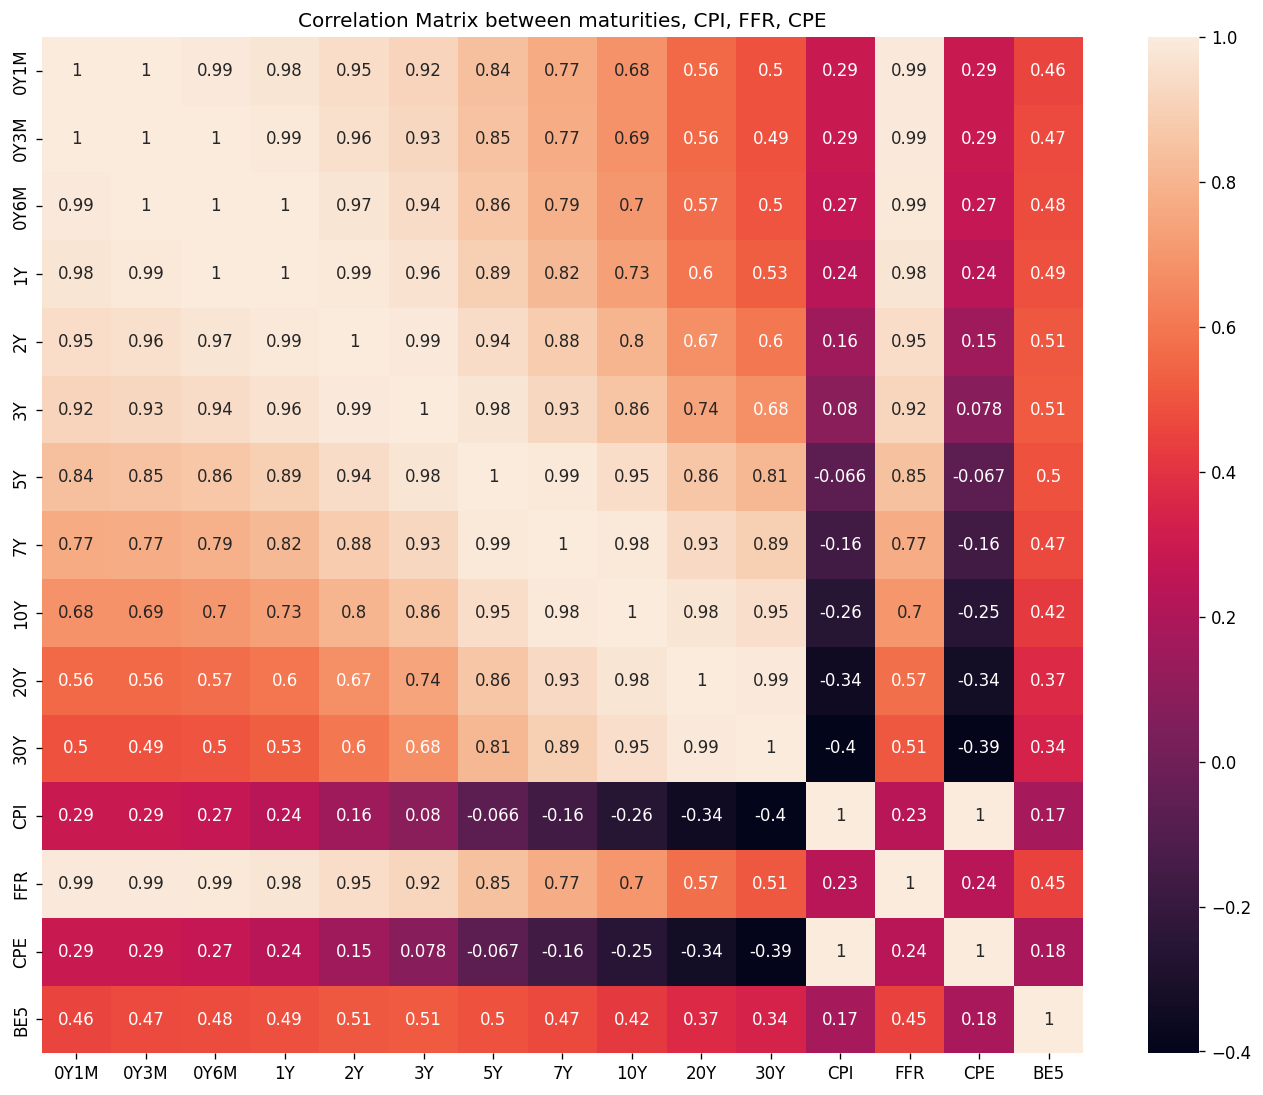

In [27]:
#Inflation metric
CPI = pd.read_csv("../data/CPI_LESSFOOD+ENERGY.csv").dropna()
CPI.rename(columns={"observation_date": "Date", "CPILFESL":"CPI"}, inplace=True)
CPI["Date"] = pd.to_datetime(CPI["Date"])
CPI.set_index("Date", inplace=True)


FFR = pd.read_csv("../data/DFF.csv").dropna()
FFR.rename(columns={"observation_date": "Date", "DFF":"FFR"}, inplace=True)
FFR["Date"] = pd.to_datetime(FFR["Date"])
FFR.set_index("Date", inplace=True)


CPE = pd.read_csv("../data/PCEPILFE.csv").dropna()
CPE.rename(columns={"observation_date": "Date", "PCEPILFE":"CPE"}, inplace=True)
CPE["Date"] = pd.to_datetime(CPE["Date"])
CPE.set_index("Date", inplace=True)

MATURITIES = pd.read_csv("../data/FRB_H15.csv").dropna()
MATURITIES.rename(columns={"Series Description": "Date", "Market yield on U.S. Treasury securities at 1-month  constant maturity, quoted on investment basis": "0Y1M", "Market yield on U.S. Treasury securities at 3-month  constant maturity, quoted on investment basis": "0Y3M", "Market yield on U.S. Treasury securities at 6-month  constant maturity, quoted on investment basis": "0Y6M", "Market yield on U.S. Treasury securities at 1-year  constant maturity, quoted on investment basis": "1Y", "Market yield on U.S. Treasury securities at 2-year  constant maturity, quoted on investment basis": "2Y", "Market yield on U.S. Treasury securities at 3-year  constant maturity, quoted on investment basis": "3Y", "Market yield on U.S. Treasury securities at 5-year  constant maturity, quoted on investment basis": "5Y", "Market yield on U.S. Treasury securities at 7-year  constant maturity, quoted on investment basis": "7Y", "Market yield on U.S. Treasury securities at 10-year  constant maturity, quoted on investment basis": "10Y", "Market yield on U.S. Treasury securities at 20-year constant maturity, quoted on investment basis": "20Y", "Market yield on U.S. Treasury securities at 30-year  constant maturity, quoted on investment basis": "30Y"}, inplace=True)
MATURITIES.rename(columns={"Market yield on U.S. Treasury securities at 20-year  constant maturity, quoted on investment basis": "20Y"}, inplace=True)

#make index to datetime for timeseries
MATURITIES["Date"] = pd.to_datetime(MATURITIES["Date"])
MATURITIES.set_index("Date", inplace=True)

BE = pd.read_csv("../data/T5YIE.csv").dropna()
BE.rename(columns = {"observation_date": "Date", "T5YIE": "BE5"}, inplace=True)
BE["Date"] = pd.to_datetime(BE["Date"])
BE.set_index("Date", inplace=True)

combined_df = MATURITIES.join(
    [CPI,
    FFR,
    CPE,
    BE
    ],
    how="left"
)

combined_df = combined_df.sort_index()
combined_df.head(5)
#CPE and CPI are released monthly
# FED sets federal funds rate target, but actual value fluctuates daily based on banks

matrix = combined_df.corr()

fig,ax = plt.subplots(
    figsize = (14,11),
    dpi = 120
)

ax2 = sns.heatmap(
    matrix,
    annot=True,
    ax=ax
)
plt.title("Correlation Matrix between maturities, CPI, FFR, CPE")
plt.show()

grid = ax2.get_figure()
grid.savefig("correlationMatrix.png")